<a href="https://colab.research.google.com/github/rmoraru26/EEG-Seizure-Detection/blob/main/EEG_Seizure_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEG-Based Epileptic Seizure Detection

This project develops a ML pipeline for detecting epileptic seizure activity in scalp EEG recordings from the CHB-MIT dataset. The pipeline includes EEG filtering, segmentation, time- and frequency-domain feature extraction, patient-wise model evaluation,and model interpretability.

In [1]:
!pip install -q mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 42.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
import mne

print("MNE version:", mne.__version__)
print("MNE installed successfully!")

MNE version: 1.13.2
MNE installed successfully!


The project uses selected recordings from the CHB-MIT Scalp EEG Database, available through PhysioNet. The recordings contain multichannel scalp EEG signals sampled at 256 Hz, together with expert-annotated seizure intervals.Only selected recordings are downloaded temporarily during execution. The original EDF files are not stored in this repository.

In [3]:
!mkdir -p /content/data

!wget -q --show-progress \
https://physionet.org/files/chbmit/1.0.0/chb01/chb01_01.edf \
-P /content/data

!wget -q --show-progress \
https://physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf \
-P /content/data

!wget -q \
https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt \
-P /content/data

chb01_01.edf        100%[===================>]  40.44M   198KB/s    in 3m 32s  
chb01_03.edf        100%[===================>]  40.44M   204KB/s    in 3m 37s  


In [4]:
import os

data_folder = "/content/data"

for file_name in os.listdir(data_folder):
    file_path = os.path.join(data_folder, file_name)
    size_mb = os.path.getsize(file_path) / (1024 ** 2)
    print(f"{file_name}: {size_mb:.2f} MB")

chb01_03.edf: 40.44 MB
chb01_01.edf: 40.44 MB
chb01-summary.txt: 0.01 MB


In [5]:
summary_path = "/content/data/chb01-summary.txt"

with open(summary_path, "r") as file:
    summary_text = file.read()

start = summary_text.find("File Name: chb01_03.edf")
end = summary_text.find("File Name:", start + 10)

print(summary_text[start:end])

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds




In [6]:
import mne

seizure_file = "/content/data/chb01_03.edf"

raw = mne.io.read_raw_edf(
    seizure_file,
    preload=False,
    verbose=False
)

sampling_frequency = raw.info["sfreq"]
duration_seconds = raw.n_times / sampling_frequency

print(f"Sampling frequency: {sampling_frequency} Hz")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Duration: {duration_seconds / 60:.2f} minutes")
print("\nChannel names:")
print(raw.ch_names)

Sampling frequency: 256.0 Hz
Number of channels: 23
Duration: 60.00 minutes

Channel names:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


/tmp/ipykernel_679/3501643739.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(




The EEG signals are band-pass filtered between 0.5 and 40 Hz. Normal interictal activity is compared with ictal activity recorded during an
annotated seizure.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

sfreq = int(raw.info["sfreq"])

selected_channels = [
    "FP1-F7",
    "F7-T7",
    "T7-P7",
    "P7-O1",
    "FP1-F3"
]

def get_filtered_segment(raw, start_time, duration, channels):
    start_sample = int(start_time * sfreq)
    stop_sample = int((start_time + duration) * sfreq)

    data = raw.get_data(
        picks=channels,
        start=start_sample,
        stop=stop_sample
    )

    # Convert volts to microvolts
    data = data * 1e6

    # Band-pass filter between 0.5 and 40 Hz
    sos = butter(
        4,
        [0.5, 40],
        btype="bandpass",
        fs=sfreq,
        output="sos"
    )

    return sosfiltfilt(sos, data, axis=1)


duration = 10

normal_data = get_filtered_segment(
    raw,
    start_time=1000,
    duration=duration,
    channels=selected_channels
)

seizure_data = get_filtered_segment(
    raw,
    start_time=3000,
    duration=duration,
    channels=selected_channels
)

time = np.arange(normal_data.shape[1]) / sfreq

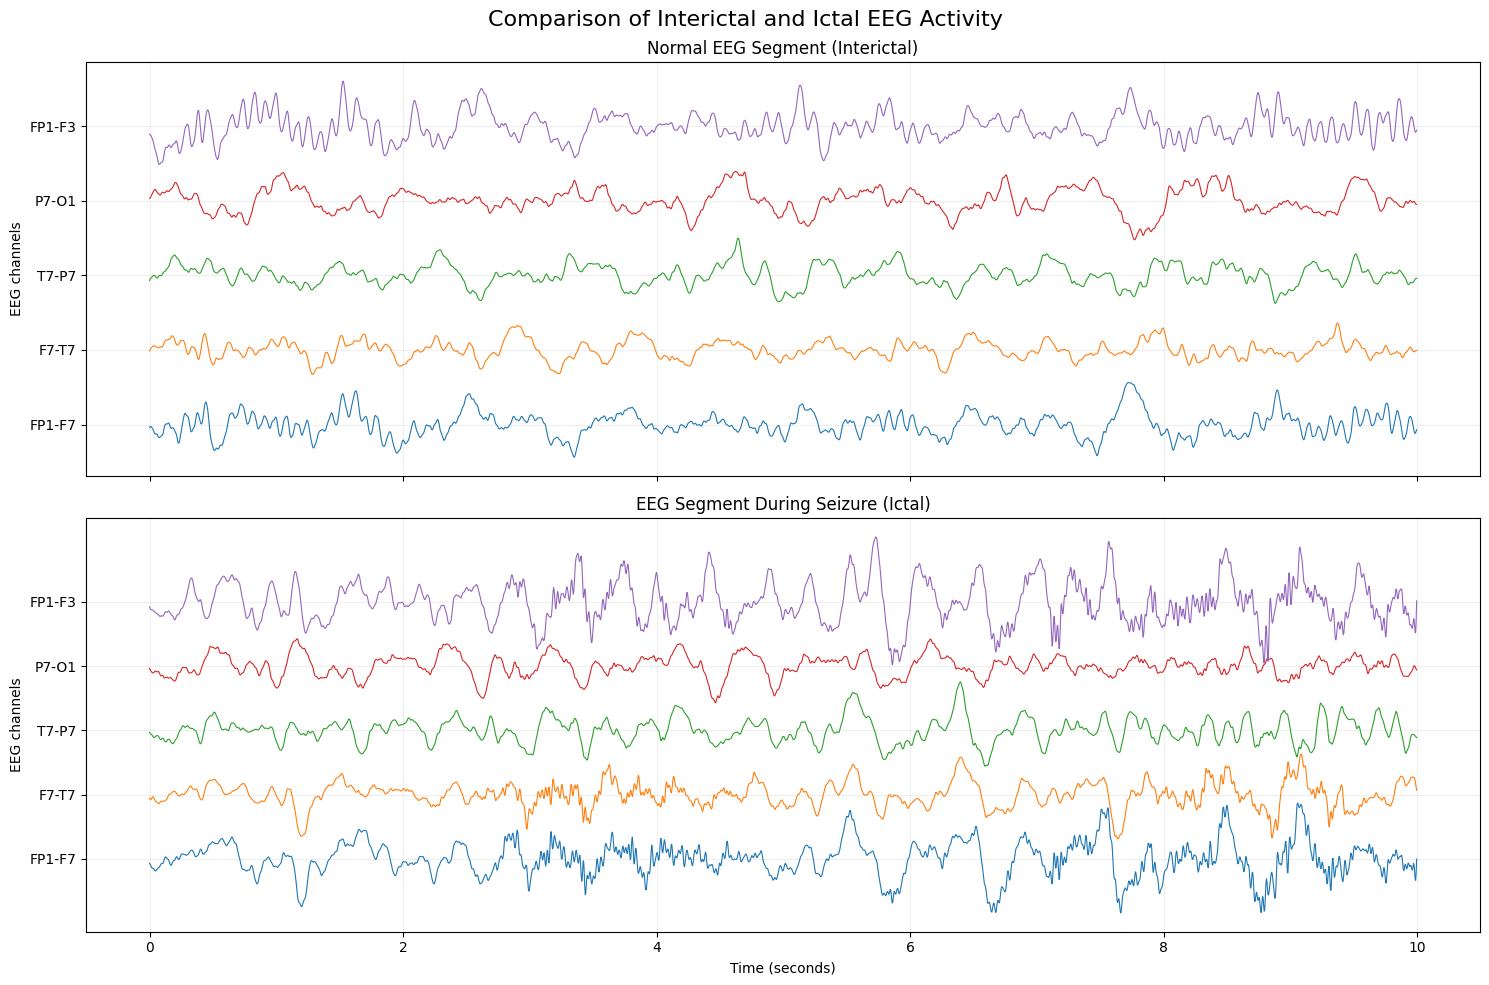

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

offset = 300

for i, channel in enumerate(selected_channels):
    axes[0].plot(time, normal_data[i] + i * offset, linewidth=0.8)
    axes[1].plot(time, seizure_data[i] + i * offset, linewidth=0.8)

axes[0].set_title("Normal EEG Segment (Interictal)")
axes[1].set_title("EEG Segment During Seizure (Ictal)")

for ax in axes:
    ax.set_yticks(np.arange(len(selected_channels)) * offset)
    ax.set_yticklabels(selected_channels)
    ax.set_ylabel("EEG channels")
    ax.grid(alpha=0.2)

axes[1].set_xlabel("Time (seconds)")

plt.suptitle(
    "Comparison of Interictal and Ictal EEG Activity",
    fontsize=16
)
plt.tight_layout()
plt.show()



Each recording is divided into two-second windows. Relative power is calculated for the delta, theta, alpha, beta, and gamma frequency bands. Time-domain features include mean absolute amplitude, standard deviation, root mean square amplitude, and line length.

In [9]:
import pandas as pd
from scipy.signal import welch

frequency_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 40)
}

def calculate_relative_bandpower(data, sfreq, bands):
    frequencies, power_spectrum = welch(
        data,
        fs=sfreq,
        nperseg=sfreq * 2,
        axis=1
    )

    # Average power across the selected EEG channels
    mean_power_spectrum = power_spectrum.mean(axis=0)

    total_mask = (frequencies >= 0.5) & (frequencies <= 40)
    total_power = np.trapezoid(
        mean_power_spectrum[total_mask],
        frequencies[total_mask]
    )

    relative_powers = {}

    for band_name, (low_frequency, high_frequency) in bands.items():
        band_mask = (
            (frequencies >= low_frequency)
            & (frequencies < high_frequency)
        )

        band_power = np.trapezoid(
            mean_power_spectrum[band_mask],
            frequencies[band_mask]
        )

        relative_powers[band_name] = band_power / total_power

    return relative_powers


normal_bandpower = calculate_relative_bandpower(
    normal_data,
    sfreq,
    frequency_bands
)

seizure_bandpower = calculate_relative_bandpower(
    seizure_data,
    sfreq,
    frequency_bands
)

bandpower_df = pd.DataFrame({
    "Normal": normal_bandpower,
    "Seizure": seizure_bandpower
})

bandpower_df

,Normal,Seizure
Delta,0.771074,0.726989
Theta,0.113455,0.164566
Alpha,0.072174,0.017088
Beta,0.008051,0.023903
Gamma,0.001241,0.010981


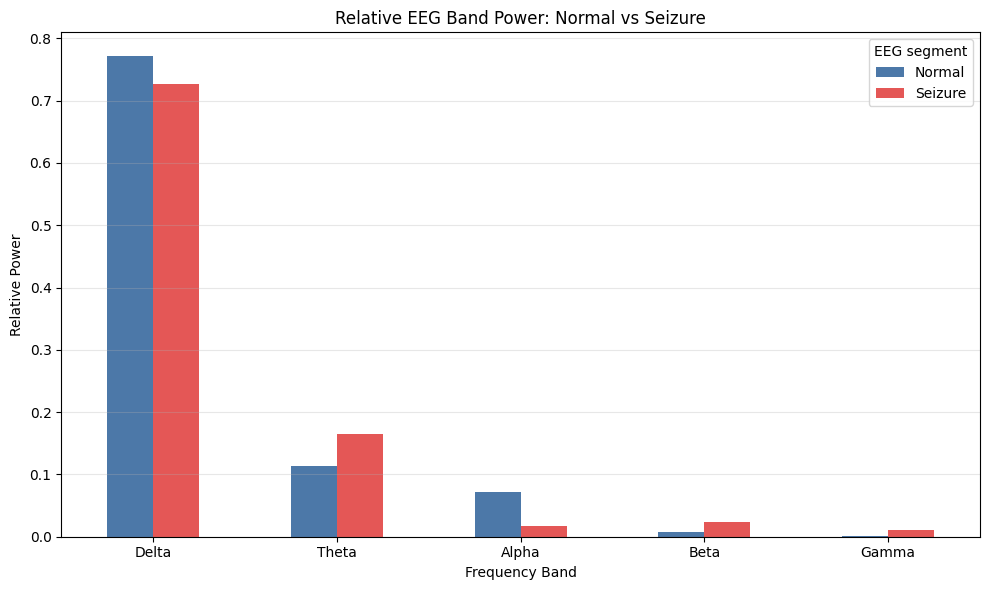

In [10]:
ax = bandpower_df.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#4C78A8", "#E45756"]
)

ax.set_title("Relative EEG Band Power: Normal vs Seizure")
ax.set_xlabel("Frequency Band")
ax.set_ylabel("Relative Power")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.legend(title="EEG segment")
plt.tight_layout()
plt.show()

In [11]:
def extract_window_features(window, sfreq):
    features = {}

    # Frequency-domain features
    bandpowers = calculate_relative_bandpower(
        window,
        sfreq,
        frequency_bands
    )

    for band_name, power in bandpowers.items():
        features[f"{band_name.lower()}_power"] = power

    # Time-domain features
    features["mean_absolute_amplitude"] = np.mean(np.abs(window))
    features["standard_deviation"] = np.std(window)
    features["rms"] = np.sqrt(np.mean(window ** 2))
    features["line_length"] = np.mean(
        np.abs(np.diff(window, axis=1))
    )

    return features


def create_windows(raw, start_time, end_time, window_duration, label):
    rows = []
    current_time = start_time

    while current_time + window_duration <= end_time:
        window = get_filtered_segment(
            raw,
            start_time=current_time,
            duration=window_duration,
            channels=selected_channels
        )

        features = extract_window_features(window, sfreq)
        features["start_time"] = current_time
        features["label"] = label

        rows.append(features)
        current_time += window_duration

    return rows

In [12]:
window_duration = 2

# A normal 40-second interval from the same recording
normal_rows = create_windows(
    raw,
    start_time=2000,
    end_time=2040,
    window_duration=window_duration,
    label=0
)

# The annotated seizure interval
seizure_rows = create_windows(
    raw,
    start_time=2996,
    end_time=3036,
    window_duration=window_duration,
    label=1
)

features_df = pd.DataFrame(normal_rows + seizure_rows)

print("Dataset shape:", features_df.shape)
print("\nClass distribution:")
print(features_df["label"].value_counts())

features_df.head()

Dataset shape: (40, 11)

Class distribution:
label
0    20
1    20
Name: count, dtype: int64


,delta_power,theta_power,alpha_power,beta_power,gamma_power,mean_absolute_amplitude,standard_deviation,rms,line_length,start_time,label
0,0.559598,0.266763,0.048301,0.059727,0.004310,18.394646,23.964496,23.993674,2.716091,2000,0
1,0.473671,0.294600,0.047755,0.042069,0.006299,16.918821,22.282173,22.291448,2.333107,2002,0
2,0.524960,0.276168,0.044610,0.061617,0.006106,21.317425,27.041982,27.086085,2.820392,2004,0
3,0.570602,0.230042,0.043181,0.110733,0.004683,21.385687,27.577817,27.600897,3.360794,2006,0
4,0.614397,0.220463,0.031692,0.056630,0.005630,20.073695,26.123265,26.300019,2.617823,2008,0


In [13]:
import os
import requests

base_url = "https://physionet.org/files/chbmit/1.0.0"
subjects = ["chb01", "chb02", "chb03", "chb05", "chb08"]

# Official list of recordings containing seizures
records_url = f"{base_url}/RECORDS-WITH-SEIZURES"
records_text = requests.get(records_url).text
seizure_records = records_text.strip().splitlines()

selected_records = {}

for subject in subjects:
    subject_records = [
        record for record in seizure_records
        if record.startswith(f"{subject}/")
    ]

    selected_records[subject] = subject_records[0]

print("Selected recordings:")

for subject, record in selected_records.items():
    print(f"{subject}: {record}")

Selected recordings:
chb01: chb01/chb01_03.edf
chb02: chb02/chb02_16.edf
chb03: chb03/chb03_01.edf
chb05: chb05/chb05_06.edf
chb08: chb08/chb08_02.edf


In [14]:
def download_file(url, destination):
    if os.path.exists(destination):
        print(f"Already available: {os.path.basename(destination)}")
        return

    print(f"Downloading: {os.path.basename(destination)}")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(destination, "wb") as file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)

    size_mb = os.path.getsize(destination) / (1024 ** 2)
    print(f"Completed: {size_mb:.2f} MB")


for subject, record in selected_records.items():
    file_name = os.path.basename(record)

    edf_url = f"{base_url}/{record}"
    edf_destination = f"/content/data/{file_name}"

    summary_name = f"{subject}-summary.txt"
    summary_url = f"{base_url}/{subject}/{summary_name}"
    summary_destination = f"/content/data/{summary_name}"

    download_file(edf_url, edf_destination)
    download_file(summary_url, summary_destination)

Already available: chb01_03.edf
Already available: chb01-summary.txt
Downloading: chb02_16.edf
Completed: 10.78 MB
Downloading: chb02-summary.txt
Completed: 0.00 MB
Downloading: chb03_01.edf
Completed: 40.44 MB
Downloading: chb03-summary.txt
Completed: 0.00 MB
Downloading: chb05_06.edf
Completed: 40.44 MB
Downloading: chb05-summary.txt
Completed: 0.00 MB
Downloading: chb08_02.edf
Completed: 40.44 MB
Downloading: chb08-summary.txt
Completed: 0.00 MB


In [15]:
print("\nDownloaded files:")

for file_name in sorted(os.listdir("/content/data")):
    file_path = os.path.join("/content/data", file_name)
    size_mb = os.path.getsize(file_path) / (1024 ** 2)
    print(f"{file_name}: {size_mb:.2f} MB")


Downloaded files:
chb01-summary.txt: 0.01 MB
chb01_01.edf: 40.44 MB
chb01_03.edf: 40.44 MB
chb02-summary.txt: 0.00 MB
chb02_16.edf: 10.78 MB
chb03-summary.txt: 0.00 MB
chb03_01.edf: 40.44 MB
chb05-summary.txt: 0.00 MB
chb05_06.edf: 40.44 MB
chb08-summary.txt: 0.00 MB
chb08_02.edf: 40.44 MB


In [16]:
import re

def extract_seizure_intervals(summary_path, edf_file_name):
    with open(summary_path, "r") as file:
        text = file.read()

    pattern = (
        rf"File Name:\s*{re.escape(edf_file_name)}"
        rf"(.*?)(?=File Name:|\Z)"
    )

    match = re.search(pattern, text, flags=re.DOTALL)

    if match is None:
        return []

    file_section = match.group(1)

    start_times = re.findall(
        r"Seizure(?: \d+)? Start Time:\s*(\d+)\s*seconds",
        file_section
    )

    end_times = re.findall(
        r"Seizure(?: \d+)? End Time:\s*(\d+)\s*seconds",
        file_section
    )

    return [
        (int(start), int(end))
        for start, end in zip(start_times, end_times)
    ]


patient_information = []

for subject, record in selected_records.items():
    edf_file_name = os.path.basename(record)
    summary_path = f"/content/data/{subject}-summary.txt"

    intervals = extract_seizure_intervals(
        summary_path,
        edf_file_name
    )

    patient_information.append({
        "patient_id": subject,
        "file_name": edf_file_name,
        "seizure_intervals": intervals
    })

    print(f"{subject} | {edf_file_name} | {intervals}")

chb01 | chb01_03.edf | [(2996, 3036)]
chb02 | chb02_16.edf | [(130, 212)]
chb03 | chb03_01.edf | [(362, 414)]
chb05 | chb05_06.edf | [(417, 532)]
chb08 | chb08_02.edf | [(2670, 2841)]


In [17]:
def extract_filtered_window(
    patient_raw,
    start_time,
    duration,
    channels
):
    local_sfreq = int(patient_raw.info["sfreq"])

    start_sample = int(start_time * local_sfreq)
    stop_sample = int((start_time + duration) * local_sfreq)

    data = patient_raw.get_data(
        picks=channels,
        start=start_sample,
        stop=stop_sample
    ) * 1e6

    sos = butter(
        4,
        [0.5, 40],
        btype="bandpass",
        fs=local_sfreq,
        output="sos"
    )

    return sosfiltfilt(sos, data, axis=1)


def create_patient_windows(
    patient_raw,
    start_time,
    end_time,
    label,
    patient_id,
    file_name,
    channels,
    window_duration=2
):
    rows = []
    current_time = start_time
    local_sfreq = int(patient_raw.info["sfreq"])

    while current_time + window_duration <= end_time:
        window = extract_filtered_window(
            patient_raw,
            current_time,
            window_duration,
            channels
        )

        features = extract_window_features(
            window,
            local_sfreq
        )

        features["patient_id"] = patient_id
        features["file_name"] = file_name
        features["start_time"] = current_time
        features["label"] = label

        rows.append(features)
        current_time += window_duration

    return rows

In [18]:
all_patient_rows = []

for patient in patient_information:
    patient_id = patient["patient_id"]
    file_name = patient["file_name"]
    intervals = patient["seizure_intervals"]

    if not intervals:
        print(f"No seizure interval found for {patient_id}")
        continue

    file_path = f"/content/data/{file_name}"

    patient_raw = mne.io.read_raw_edf(
        file_path,
        preload=False,
        verbose=False
    )

    available_channels = [
        channel for channel in selected_channels
        if channel in patient_raw.ch_names
    ]

    if len(available_channels) != len(selected_channels):
        print(f"Missing channels for {patient_id}")
        continue

    recording_duration = (
        patient_raw.n_times / patient_raw.info["sfreq"]
    )

    # Use the first annotated seizure in the selected file
    seizure_start, seizure_end = intervals[0]
    seizure_duration = seizure_end - seizure_start

    # Prefer a normal interval five minutes after the seizure
    normal_start = seizure_end + 300

    if normal_start + seizure_duration > recording_duration:
        # Otherwise select an interval five minutes before it
        normal_start = seizure_start - 300 - seizure_duration

    if normal_start < 0:
        normal_start = 0

    normal_end = normal_start + seizure_duration

    normal_rows = create_patient_windows(
        patient_raw,
        normal_start,
        normal_end,
        label=0,
        patient_id=patient_id,
        file_name=file_name,
        channels=available_channels
    )

    seizure_rows = create_patient_windows(
        patient_raw,
        seizure_start,
        seizure_end,
        label=1,
        patient_id=patient_id,
        file_name=file_name,
        channels=available_channels
    )

    all_patient_rows.extend(normal_rows)
    all_patient_rows.extend(seizure_rows)

    print(
        f"{patient_id}: "
        f"{len(normal_rows)} normal, "
        f"{len(seizure_rows)} seizure windows"
    )

multi_patient_df = pd.DataFrame(all_patient_rows)

/tmp/ipykernel_679/3673814147.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  patient_raw = mne.io.read_raw_edf(


chb01: 20 normal, 20 seizure windows


/tmp/ipykernel_679/3673814147.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  patient_raw = mne.io.read_raw_edf(


chb02: 41 normal, 41 seizure windows


/tmp/ipykernel_679/3673814147.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  patient_raw = mne.io.read_raw_edf(


chb03: 26 normal, 26 seizure windows


/tmp/ipykernel_679/3673814147.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  patient_raw = mne.io.read_raw_edf(


chb05: 57 normal, 57 seizure windows


/tmp/ipykernel_679/3673814147.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  patient_raw = mne.io.read_raw_edf(


chb08: 85 normal, 85 seizure windows


In [19]:
print("Complete dataset shape:", multi_patient_df.shape)

class_counts = pd.crosstab(
    multi_patient_df["patient_id"],
    multi_patient_df["label"]
)

class_counts.columns = ["Normal", "Seizure"]
display(class_counts)

display(multi_patient_df.head())

Complete dataset shape: (458, 13)


,Normal,Seizure
patient_id,,
chb01,20,20
chb02,41,41
chb03,26,26
chb05,57,57
chb08,85,85


,delta_power,theta_power,alpha_power,beta_power,gamma_power,mean_absolute_amplitude,standard_deviation,rms,line_length,patient_id,file_name,start_time,label
0,0.697195,0.132331,0.023960,0.060366,0.035230,18.440549,23.394036,23.520878,3.335708,chb01,chb01_03.edf,3336,0
1,0.504682,0.248485,0.037342,0.074508,0.046272,17.202614,22.769644,23.014725,3.374119,chb01,chb01_03.edf,3338,0
2,0.537502,0.269298,0.071240,0.046631,0.016089,27.469048,36.593985,36.605887,4.729327,chb01,chb01_03.edf,3340,0
3,0.686937,0.131202,0.033732,0.067619,0.031108,23.404924,29.613582,29.620500,3.665488,chb01,chb01_03.edf,3342,0
4,0.663856,0.155949,0.027548,0.060701,0.039599,18.789081,23.518035,23.580911,3.274695,chb01,chb01_03.edf,3344,0


In [20]:
feature_columns = [
    "delta_power",
    "theta_power",
    "alpha_power",
    "beta_power",
    "gamma_power",
    "mean_absolute_amplitude",
    "standard_deviation",
    "rms",
    "line_length"
]

X = multi_patient_df[feature_columns]
y = multi_patient_df["label"]
groups = multi_patient_df["patient_id"]

print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("Number of patients:", groups.nunique())
print("\nMissing values:")
print(X.isna().sum())

Number of samples: 458
Number of features: 9
Number of patients: 5

Missing values:
delta_power                0
theta_power                0
alpha_power                0
beta_power                 0
gamma_power                0
mean_absolute_amplitude    0
standard_deviation         0
rms                        0
line_length                0
dtype: int64




Logistic Regression, Random Forest, and Support Vector Machine classifiers are compared using Leave-One-Patient-Out Cross-Validation. During each
fold, all windows from one patient are reserved for testing, preventing patient-level data leakage.

In [21]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ])
}

In [22]:
logo = LeaveOneGroupOut()
evaluation_rows = []
all_predictions = {}

for model_name, model in models.items():
    model_predictions = []

    for train_indices, test_indices in logo.split(X, y, groups):
        X_train = X.iloc[train_indices]
        X_test = X.iloc[test_indices]

        y_train = y.iloc[train_indices]
        y_test = y.iloc[test_indices]

        test_patient = groups.iloc[test_indices].iloc[0]

        fold_model = clone(model)
        fold_model.fit(X_train, y_train)

        y_pred = fold_model.predict(X_test)
        y_probability = fold_model.predict_proba(X_test)[:, 1]

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            y_pred,
            labels=[0, 1]
        ).ravel()

        specificity = tn / (tn + fp)

        evaluation_rows.append({
            "model": model_name,
            "test_patient": test_patient,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(
                y_test,
                y_pred
            ),
            "precision": precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            "sensitivity": recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            "specificity": specificity,
            "f1_score": f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            "roc_auc": roc_auc_score(
                y_test,
                y_probability
            )
        })

        model_predictions.extend([
            {
                "patient_id": patient,
                "true_label": true_label,
                "predicted_label": predicted_label,
                "probability": probability
            }
            for patient, true_label, predicted_label, probability
            in zip(
                groups.iloc[test_indices],
                y_test,
                y_pred,
                y_probability
            )
        ])

    all_predictions[model_name] = pd.DataFrame(model_predictions)

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df

,model,test_patient,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1_score,roc_auc
0,Logistic Regression,chb01,0.625000,0.625000,0.727273,0.400000,0.850000,0.516129,0.832500
1,Logistic Regression,chb02,0.841463,0.841463,0.804348,0.902439,0.780488,0.850575,0.897680
2,Logistic Regression,chb03,0.903846,0.903846,1.000000,0.807692,1.000000,0.893617,0.963018
3,Logistic Regression,chb05,0.763158,0.763158,0.678571,1.000000,0.526316,0.808511,0.991998
4,Logistic Regression,chb08,0.711765,0.711765,0.950000,0.447059,0.976471,0.608000,0.808028
5,Random Forest,chb01,0.675000,0.675000,1.000000,0.350000,1.000000,0.518519,0.836250
6,Random Forest,chb02,0.865854,0.865854,0.826087,0.926829,0.804878,0.873563,0.945271
7,Random Forest,chb03,0.788462,0.788462,0.826087,0.730769,0.846154,0.775510,0.889053
8,Random Forest,chb05,0.719298,0.719298,0.640449,1.000000,0.438596,0.780822,0.836257
9,Random Forest,chb08,0.741176,0.741176,0.901961,0.541176,0.941176,0.676471,0.795571




Logistic Regression achieved the strongest overall performance:

- Mean accuracy: 76.9%
- Mean sensitivity: 71.1%
- Mean specificity: 82.7%
- Mean F1-score: 73.5%
- Mean ROC-AUC: 89.9%

Performance varied between patients, demonstrating the challenge of
generalizing seizure-detection models to previously unseen individuals.

In [23]:
model_summary = (
    evaluation_df
    .groupby("model")
    [[
        "accuracy",
        "balanced_accuracy",
        "precision",
        "sensitivity",
        "specificity",
        "f1_score",
        "roc_auc"
    ]]
    .agg(["mean", "std"])
    .round(3)
)

model_summary

accuracy        balanced_accuracy        precision         \
                        mean    std              mean    std      mean    std   
model                                                                           
Logistic Regression    0.769  0.109             0.769  0.109     0.832  0.139   
Random Forest          0.758  0.073             0.758  0.073     0.839  0.132   
SVM                    0.673  0.111             0.673  0.111     0.721  0.157   

                    sensitivity        specificity        f1_score         \
                           mean    std        mean    std     mean    std   
model                                                                       
Logistic Regression       0.711  0.272       0.827  0.191    0.735  0.164   
Random Forest             0.710  0.269       0.806  0.219    0.725  0.135   
SVM                       0.640  0.275       0.707  0.274    0.644  0.150   

                    roc_auc         
                       mean    std  
model                               
Logistic Regression   0.899  0.080  
Random Forest         0.860  0.058  
SVM                   0.715  0.195

In [24]:
from google.colab import drive
import os

drive.mount("/content/drive")

project_folder = (
    "/content/drive/MyDrive/"
    "epileptic-seizure-detection"
)

results_folder = f"{project_folder}/results"
os.makedirs(results_folder, exist_ok=True)

print("Results folder:", results_folder)

Mounted at /content/drive
Results folder: /content/drive/MyDrive/epileptic-seizure-detection/results


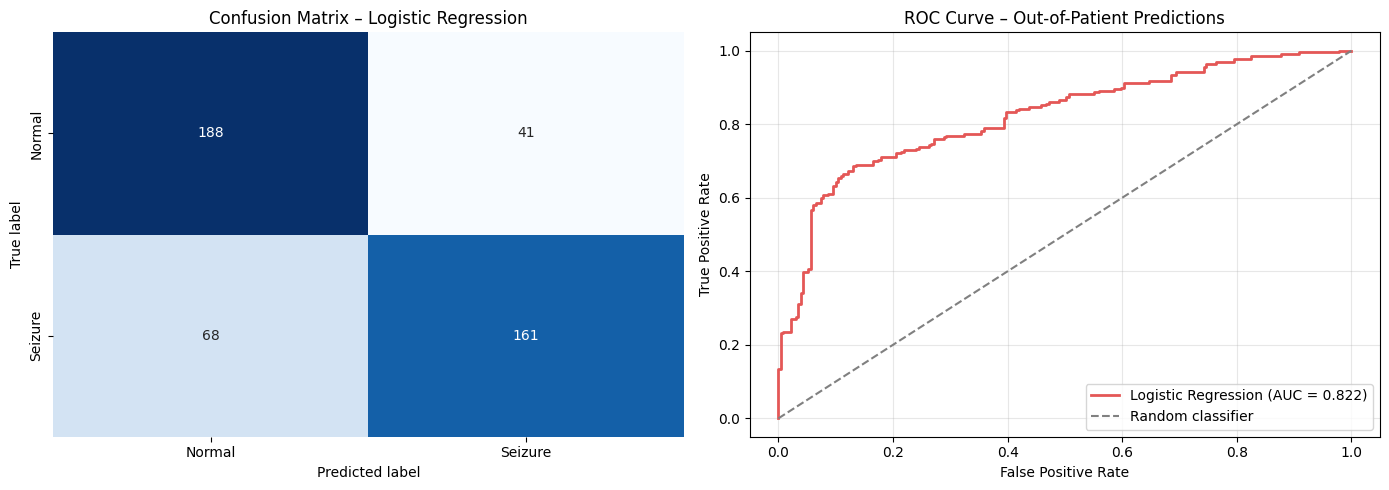

Saved to: /content/drive/MyDrive/epileptic-seizure-detection/results/logistic_regression_evaluation.png


In [25]:
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

best_model_name = "Logistic Regression"
best_predictions = all_predictions[best_model_name]

y_true = best_predictions["true_label"]
y_pred = best_predictions["predicted_label"]
y_probability = best_predictions["probability"]

cm = confusion_matrix(y_true, y_pred)

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_probability
)

pooled_auc = roc_auc_score(
    y_true,
    y_probability
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Seizure"],
    yticklabels=["Normal", "Seizure"],
    ax=axes[0]
)

axes[0].set_title(
    "Confusion Matrix – Logistic Regression"
)
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

axes[1].plot(
    fpr,
    tpr,
    color="#E45756",
    linewidth=2,
    label=f"Logistic Regression (AUC = {pooled_auc:.3f})"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

axes[1].set_title("ROC Curve – Out-of-Patient Predictions")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()

figure_path = (
    f"{results_folder}/"
    "logistic_regression_evaluation.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", figure_path)

In [26]:
evaluation_df.to_csv(
    f"{results_folder}/patient_level_metrics.csv",
    index=False
)

best_predictions.to_csv(
    f"{results_folder}/out_of_patient_predictions.csv",
    index=False
)

multi_patient_df.to_csv(
    f"{results_folder}/extracted_features.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [27]:
from sklearn.base import clone
import joblib

final_model = clone(models["Logistic Regression"])
final_model.fit(X, y)

print("Final model trained on all available data.")

Final model trained on all available data.


In [28]:
classifier = final_model.named_steps["classifier"]

coefficient_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": classifier.coef_[0]
})

coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "absolute_coefficient",
    ascending=True
)

coefficient_df

,feature,coefficient,absolute_coefficient
3,beta_power,0.652389,0.652389
4,gamma_power,-0.666145,0.666145
6,standard_deviation,-0.728728,0.728728
7,rms,-0.743224,0.743224
2,alpha_power,0.809678,0.809678
1,theta_power,0.983640,0.983640
0,delta_power,1.640815,1.640815
5,mean_absolute_amplitude,2.377523,2.377523
8,line_length,2.737499,2.737499


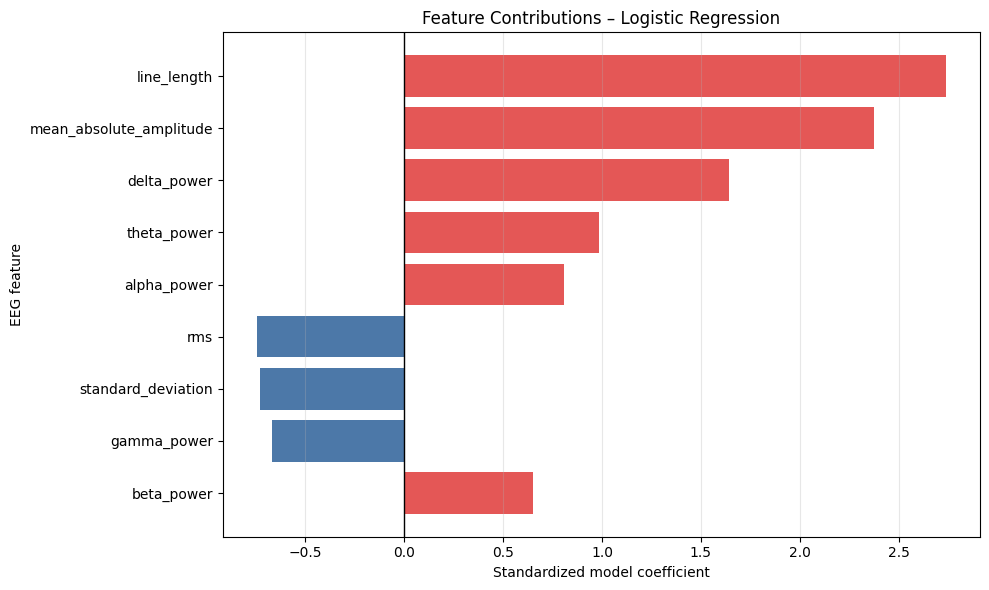

Saved to: /content/drive/MyDrive/epileptic-seizure-detection/results/feature_contributions.png


In [29]:
colors = [
    "#E45756" if value > 0 else "#4C78A8"
    for value in coefficient_df["coefficient"]
]

plt.figure(figsize=(10, 6))

plt.barh(
    coefficient_df["feature"],
    coefficient_df["coefficient"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Feature Contributions – Logistic Regression"
)
plt.xlabel("Standardized model coefficient")
plt.ylabel("EEG feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

feature_figure_path = (
    f"{results_folder}/feature_contributions.png"
)

plt.savefig(
    feature_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", feature_figure_path)

In [30]:
import json

models_folder = f"{project_folder}/models"
os.makedirs(models_folder, exist_ok=True)

model_path = (
    f"{models_folder}/"
    "logistic_regression_seizure_detector.joblib"
)

joblib.dump(final_model, model_path)

model_metadata = {
    "model": "Logistic Regression",
    "task": "EEG seizure-window classification",
    "dataset": "CHB-MIT Scalp EEG Database",
    "patients_used": sorted(groups.unique().tolist()),
    "number_of_patients": int(groups.nunique()),
    "number_of_windows": int(len(X)),
    "window_duration_seconds": 2,
    "sampling_frequency_hz": 256,
    "frequency_range_hz": [0.5, 40],
    "selected_channels": selected_channels,
    "feature_columns": feature_columns,
    "validation": "Leave-One-Patient-Out Cross-Validation",
    "limitations": [
        "Research and educational use only",
        "Trained on a small pediatric patient subset",
        "Not validated for clinical diagnosis or monitoring"
    ]
}

metadata_path = f"{models_folder}/model_metadata.json"

with open(metadata_path, "w") as file:
    json.dump(
        model_metadata,
        file,
        indent=4
    )

coefficient_df.to_csv(
    f"{results_folder}/feature_coefficients.csv",
    index=False
)

print("Model saved to:", model_path)
print("Metadata saved to:", metadata_path)

Model saved to: /content/drive/MyDrive/epileptic-seizure-detection/models/logistic_regression_seizure_detector.joblib
Metadata saved to: /content/drive/MyDrive/epileptic-seizure-detection/models/model_metadata.json




 The experiment uses only five pediatric patients.
 Only selected EEG channels and recordings are included. Adjacent windows from the same seizure are temporally correlated.The model has not been externally or clinically validated.The saved model is intended only as a reproducible research demonstration.Future work should include additional patients, nested hyperparameter
selection, artifact handling, channel-level features, and external
validation.